# 因子核对工具 — 研究环境 vs 实时测试环境

> 用途：将 `save_files/{symbol}/factors_*.csv` 与研究环境 `all_factor.feather` 按**时间（HH:MM:SS）**对齐，并排显示原始数字，快速定位差异。

## 使用说明
1. 修改 **配置区** 的 `symbol` 和 `research_date`
2. 依次运行每个 Cell
3. 重点查看 **"问题因子详情"** 和 **"单因子走势对比"**

### 日期映射规则
- 如果 `research_date = None`：自动在研究环境找与实时数据**时间范围匹配**的最近交易日
- 如果回放历史数据（如 20260324），建议直接指定 `research_date = "2026-03-24"`

### 关于阈值
- 默认阈值相对宽松，目的是筛出**明显异常**的因子
- 日级别因子（如 `day_jump`）在夜盘场景下天然容易对不上，请结合原始值人工判断


In [1]:
# ==================== 配置区 ====================
symbol = "P"                       # 品种: P, A, M, Y, C, CS, B, LH
# 研究环境比对日期（手动指定，None=自动匹配）
research_date = None

# 实时因子来源：factor_cache（最新路径）
FACTOR_CACHE_ROOT = "/home/strategy_PAMY_dev/factor_cache"
# 回放的日期（与 factor_cache 子目录对应，如 2026-03-23）
# 支持多日期：遍历 factor_cache 下所有子目录
cache_dates = None   # None=自动读取所有日期；或指定 ["2026-03-23"]

# 实时行情数据（1min）来源
RT_MIN_PREFIX = "/home/strategy_PAMY_dev/save_files"

# 研究环境
research_prefix = "/mnt/Data/writable/liaoyuyang/factor"

# 差异阈值
TOL_ABS = 0.01
TOL_REL = 0.05
TAIL_N = 10
DROP_COLS = {'datetime', 'instrument', 'hour'}
# =================================================


In [2]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '/home/strategy_PAMY_dev')
from strategies import get_trading_day

# 设置显示选项
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.6f}' if pd.notna(x) else 'NaN')


In [3]:
# ------------------- 读取实时因子（factor_cache）-------------------
from pathlib import Path

cache_root = Path(FACTOR_CACHE_ROOT)
if cache_dates is None:
    cache_dates = sorted([d.name for d in cache_root.iterdir() if d.is_dir()])
    print(f"[factor_cache] 发现日期: {cache_dates}")

rt_dfs = []
for d in cache_dates:
    cache_dir = cache_root / d
    rt_files = sorted(cache_dir.glob(f"{symbol}_fac_*.parquet"))
    for f in rt_files:
        rt_dfs.append(pd.read_parquet(f))

if not rt_dfs:
    raise FileNotFoundError(f"未找到实时因子: {cache_root}/{symbol}_fac_*.parquet")

rt_df = pd.concat(rt_dfs).sort_index()

# 确保 datetime 是 index
if 'datetime' in rt_df.columns:
    rt_df['datetime'] = pd.to_datetime(rt_df['datetime'])
    rt_df = rt_df.set_index('datetime').sort_index()

# 时间范围
rt_first_dt = rt_df.index[0]
rt_last_dt = rt_df.index[-1]
rt_time_min = rt_first_dt.time()
rt_time_max = rt_last_dt.time()

# 判断实时数据中是否包含夜盘/白天盘
has_night = (rt_df.index.hour >= 20).any()
has_day = (rt_df.index.hour < 20).any()

# factor_cache 中的 datetime 已经是正确日历日期，无需还原
print(f"[实时因子] 文件数: {len(rt_dfs)}")
print(f"[实时因子] 时间范围: {rt_first_dt} ~ {rt_last_dt}")
print(f"[实时因子] 总行数: {len(rt_df)}")
print(f"[实时因子] 含夜盘: {has_night}, 含白天盘: {has_day}")


[factor_cache] 发现日期: ['2026-03-17', '2026-03-18', '2026-03-19', '2026-03-20', '2026-03-23', '2026-05-26']
[实时因子] 文件数: 5
[实时因子] 时间范围: 2026-03-17 21:01:00 ~ 2026-05-25 21:14:00
[实时因子] 总行数: 1394
[实时因子] 含夜盘: True, 含白天盘: True


In [4]:
# ------------------- 读取研究环境元数据 -------------------
research_path = Path(research_prefix) / symbol / "all_fac" / "all_factor.feather"
if not research_path.exists():
    raise FileNotFoundError(f"未找到研究环境因子文件: {research_path}")

meta = pd.read_feather(research_path, columns=['datetime', 'instrument'])
meta['datetime'] = pd.to_datetime(meta['datetime'])
meta['date'] = meta['datetime'].dt.date
meta['time'] = meta['datetime'].dt.time
meta['hour'] = meta['datetime'].dt.hour

all_dates = sorted(meta['date'].unique())
print(f"[研究环境] 总交易日数: {len(all_dates)}, 最新: {all_dates[-1]}")

# 从实时数据推导需要比对的日期
rt_dates = set(rt_df.index.date)
if has_night:
    night_dates = set(rt_df.index[rt_df.index.hour >= 20].date)
else:
    night_dates = set()
if has_day:
    day_dates = set(rt_df.index[rt_df.index.hour < 20].date)
else:
    day_dates = set()

# 确定需要读取的日期
dates_needed = rt_dates & set(all_dates)

# 策略1: 如果用户指定了日期，优先使用
if research_date is not None:
    target_date = pd.to_datetime(research_date).date()
    if target_date in all_dates:
        dates_needed = {target_date}
        print(f"[用户指定] 使用日期: {target_date}")
    else:
        closest = min(all_dates, key=lambda d: abs(pd.to_datetime(d).date() - target_date))
        dates_needed = {closest}
        print(f"⚠️ 指定日期 {target_date} 无数据, 自动切换到最近日期: {closest}")
else:
    if not dates_needed:
        print(f"⚠️ 实时数据日期 {rt_dates} 与研究环境无交集，尝试自动匹配")
        # fallback: 找包含实时时间范围的最近日期
        rt_time_min = rt_df.index.min().time()
        rt_time_max = rt_df.index.max().time()
        has_min = set(meta[meta['time'] == rt_time_min]['date'].unique())
        has_max = set(meta[meta['time'] == rt_time_max]['date'].unique())
        candidates = has_min & has_max
        if candidates:
            dates_needed = {max(candidates)}
            print(f"[自动匹配] 找包含时间范围 {rt_time_min}~{rt_time_max} 的最近日期: {max(candidates)}")
        else:
            dates_needed = {all_dates[-1]}
            print(f"[自动匹配] fallback到最新日期: {all_dates[-1]}")
    else:
        print(f"[自动匹配] 实时数据日期与研究环境交集: {sorted(dates_needed)}")

# 获取合约代码（用第一个存在的日期）
first_date = next((d for d in dates_needed if d in all_dates), None)
if first_date is None:
    raise ValueError(f"指定日期 {dates_needed} 在研究环境中均无数据")

meta_target = meta[meta['date'].isin(dates_needed)]
research_instrument = meta_target['instrument'].iloc[0]
print(f"[研究环境] 比对日期: {sorted(dates_needed)}, 合约: {research_instrument}, 总分钟数: {len(meta_target)}")


[研究环境] 总交易日数: 1269, 最新: 2026-05-07
[自动匹配] 实时数据日期与研究环境交集: [datetime.date(2026, 3, 17), datetime.date(2026, 3, 18), datetime.date(2026, 3, 19), datetime.date(2026, 3, 20), datetime.date(2026, 3, 23)]
[研究环境] 比对日期: [datetime.date(2026, 3, 17), datetime.date(2026, 3, 18), datetime.date(2026, 3, 19), datetime.date(2026, 3, 20), datetime.date(2026, 3, 23)], 合约: p2605, 总分钟数: 1725


In [5]:
# ------------------- 读取研究环境完整因子 -------------------
print("正在读取研究环境因子表，请稍候...")
fac_all = pd.read_feather(research_path)
fac_all['datetime'] = pd.to_datetime(fac_all['datetime'])

fac_parts = []
if has_night:
    fac_night = fac_all[
        (fac_all['instrument'] == research_instrument) &
        (fac_all['datetime'].dt.date.isin(dates_needed)) &
        (fac_all['datetime'].dt.hour >= 20)
    ].copy()
    fac_parts.append(fac_night)
    print(f"[研究环境] 夜盘: {len(fac_night)} 根")
if has_day:
    fac_day = fac_all[
        (fac_all['instrument'] == research_instrument) &
        (fac_all['datetime'].dt.date.isin(dates_needed)) &
        (fac_all['datetime'].dt.hour < 20)
    ].copy()
    fac_parts.append(fac_day)
    print(f"[研究环境] 白天盘: {len(fac_day)} 根")

fac_research = pd.concat(fac_parts).sort_values('datetime') if fac_parts else pd.DataFrame()
del fac_all

fac_research = fac_research.set_index('datetime')
print(f"[研究环境] 读取完成，总行数: {len(fac_research)}, 列数: {len(fac_research.columns)}")


正在读取研究环境因子表，请稍候...
[研究环境] 夜盘: 600 根
[研究环境] 白天盘: 1125 根
[研究环境] 读取完成，总行数: 1725, 列数: 1866


In [6]:
# ------------------- 日期对齐 -------------------
# 实时数据已在 Cell 3 还原为正确日历日期，直接取交集
common_index = rt_df.index.intersection(fac_research.index)
print(f"[对齐] 共有时间点: {len(common_index)} 个")
if len(common_index) == 0:
    print("⚠️ 无交集！请检查日期或时间范围。")
    print("实时环境时间样例:", rt_df.index[:3].tolist())
    print("研究环境时间样例:", fac_research.index[:3].tolist())
else:
    print("时间范围:", common_index.min().strftime('%H:%M'), "~", common_index.max().strftime('%H:%M'))

rt_subset = rt_df.loc[common_index]
research_subset = fac_research.loc[common_index]

# 提取共有因子列（排除 datetime, instrument, hour 等）
rt_cols = set(rt_subset.columns) - DROP_COLS
research_cols = set(research_subset.columns) - DROP_COLS
common_factors = sorted(rt_cols & research_cols)
only_rt = sorted(rt_cols - research_cols)
only_research = sorted(research_cols - rt_cols)

print(f"[因子] 共有: {len(common_factors)} 个")
if only_rt:
    print(f"[因子] 仅实时有: {only_rt[:10]}{'...' if len(only_rt)>10 else ''}")
if only_research:
    print(f"[因子] 仅研究有: {only_research[:10]}{'...' if len(only_research)>10 else ''}")

# 子集化
rt_subset = rt_subset[common_factors]
research_subset = research_subset[common_factors]

# 因子分类（用于后续统计）
day_factors = [f for f in common_factors if f.startswith('day_')]
cross_factors = [f for f in common_factors if '_' in f and any(s in f for s in ['_A_', '_B_', '_C_', '_CS_', '_M_', '_P_', '_Y_', '_LH_'])]
minute_factors = [f for f in common_factors if f not in day_factors and f not in cross_factors]
print(f"[分类] 日级别因子: {len(day_factors)}, 跨品种因子: {len(cross_factors)}, 其他分钟因子: {len(minute_factors)}")


[对齐] 共有时间点: 1380 个
时间范围: 21:01 ~ 15:00
[因子] 共有: 266 个
[因子] 仅研究有: ['ACD', 'AR', 'ASI', 'ATR', 'BOLLING', 'BuzzResonance', 'CCI', 'CMFmin', 'CS_P_closepctchg5_sub', 'CV']...
[分类] 日级别因子: 5, 跨品种因子: 68, 其他分钟因子: 193


In [7]:
# ------------------- Market Data Check（先核对行情再核对因子）-------------------
# 读取实时端保存的所有 min_data 并拼接
data_dir = Path(RT_MIN_PREFIX) / symbol / "data"
min_files = sorted(data_dir.glob(f"{symbol}_min_*.csv"))
if not min_files:
    print("⚠️ 未找到实时 min_data 文件")
else:
    rt_mkt_parts = []
    for f in min_files:
        rt_mkt_parts.append(pd.read_csv(f, parse_dates=['datetime']))
    rt_mkt = pd.concat(rt_mkt_parts, ignore_index=True)
    rt_mkt = rt_mkt.sort_values('datetime').drop_duplicates(subset=['datetime'], keep='last')
    rt_mkt = rt_mkt.set_index('datetime')
    print(f"[实时行情] 读取 {len(min_files)} 个文件, 拼接后共 {len(rt_mkt)} 行")
    print(f"[实时行情] 时间范围: {rt_mkt.index.min()} ~ {rt_mkt.index.max()}")

    # 研究环境 1min
    research_1min_path = Path("/mnt/Data/writable/liaoyuyang/data/1min/active") / f"main_{symbol}.csv"
    if research_1min_path.exists():
        rs_mkt = pd.read_csv(research_1min_path, parse_dates=["ts"])
        rs_mkt = rs_mkt.set_index('ts')
        print(f"[研究行情] 时间范围: {rs_mkt.index.min()} ~ {rs_mkt.index.max()}")

        # 取交集
        mkt_common = rt_mkt.index.intersection(rs_mkt.index)
        print(f"[Market] 共同时间点: {len(mkt_common)}")

        if len(mkt_common) == 0:
            print("🔴 共同时间点为 0！请检查：")
            print(f"    1) 实时数据最新日期: {rt_mkt.index.max().date()}")
            print(f"    2) 研究数据最新日期: {rs_mkt.index.max().date()}")
            print("    若日期不重叠，Market Data Check 无法进行对比，但不影响后续因子对比（只要因子数据有交集即可）。")
        elif len(mkt_common) > 0:
            mkt_cols = ['open', 'high', 'low', 'close', 'volume', 'turnover', 'open_interest']
            mkt_cols = [c for c in mkt_cols if c in rt_mkt.columns and c in rs_mkt.columns]
            if mkt_cols:
                diff_mkt = (rt_mkt.loc[mkt_common, mkt_cols] - rs_mkt.loc[mkt_common, mkt_cols]).abs()
                print("[Market] max_diff:", diff_mkt.max().to_dict())
            else:
                print("[Market] 无共同列可对比")
    else:
        print(f"⚠️ 未找到研究环境 1min: {research_1min_path}")


[实时行情] 读取 192 个文件, 拼接后共 192 行
[实时行情] 时间范围: 2026-03-23 21:01:00 ~ 2026-03-24 10:14:00
[研究行情] 时间范围: 2021-02-02 09:01:00 ~ 2026-05-07 23:00:00
[Market] 共同时间点: 192
[Market] max_diff: {'open': 0.0, 'high': 2.0, 'low': 4.0, 'close': 8.0, 'volume': 497.0, 'turnover': 48360140.0, 'open_interest': 260.0}


In [8]:
# ------------------- 原始值并排显示 -------------------
# 选择一个时间点查看（默认第一个交集时间点）
# 可以修改 view_time 来查看其他分钟，如: pd.Timestamp("2026-03-24 21:45:00")
view_time = common_index[40]

print(f"=== 时间点: {view_time.strftime('%H:%M:%S')} ===")
print(f"{'factor':<42} {'research':>16} {'realtime':>16} {'abs_diff':>14} {'rel_diff':>10} {'status':>6}")
print("="*110)

r_row = research_subset.loc[view_time]
t_row = rt_subset.loc[view_time]

problem_factors_minute = []
for fac in common_factors:
    rv = r_row[fac]
    tv = t_row[fac]
    
    if pd.isna(rv) and pd.isna(tv):
        diff_abs = 0.0
        diff_rel = 0.0
        status = "OK"
    elif pd.isna(rv) != pd.isna(tv):
        diff_abs = np.nan
        diff_rel = np.nan
        status = "NA"
    else:
        diff_abs = abs(rv - tv)
        denom = abs(rv) if abs(rv) > 1e-12 else 1.0
        diff_rel = diff_abs / denom
        if diff_abs < TOL_ABS or diff_rel < TOL_REL:
            status = "OK"
        else:
            status = "DIFF"
            problem_factors_minute.append((fac, diff_abs, diff_rel))
    
    if status != "OK":
        print(f"{fac:<42} {rv:16.6f} {tv:16.6f} {diff_abs:14.6f} {diff_rel:10.2%} {status:>6}")

print(f"该时间点差异因子数: {len(problem_factors_minute)} / {len(common_factors)}")


=== 时间点: 21:41:00 ===
factor                                             research         realtime       abs_diff   rel_diff status
bar5_trend_corr                                   -0.300000              nan            nan       nan%     NA
day_jump                                          20.000000              nan            nan       nan%     NA
zigzag                                             2.195361         3.294118       1.098757     50.05%   DIFF
该时间点差异因子数: 1 / 266


In [9]:
# Research factor table
research_subset.tail(TAIL_N).T.sort_index().round(8)


datetime,2026-03-23 14:51:00,2026-03-23 14:52:00,2026-03-23 14:53:00,2026-03-23 14:54:00,2026-03-23 14:55:00,2026-03-23 14:56:00,2026-03-23 14:57:00,2026-03-23 14:58:00,2026-03-23 14:59:00,2026-03-23 15:00:00
A_P_closepctchg20_sub,0.001015,-0.000218,-0.000210,-0.000452,-0.001644,-0.001216,0.000420,0.001626,0.000822,0.000419
A_P_closepctchg5_sub,0.000839,-0.000589,-0.000387,-0.001846,-0.002652,-0.002644,-0.001225,-0.000201,0.000856,0.000830
A_P_cvcorr10_diff,0.292921,0.325143,0.203203,0.507243,-0.532154,-0.555183,-0.584695,-0.703008,-0.352619,-0.285574
A_P_oi5_diff,0.002169,0.001349,0.000309,-0.000361,-0.000278,-0.000062,0.001089,0.001715,0.001906,0.003273
A_P_vcorr10,0.033561,0.170090,0.175370,0.227385,0.070752,0.260080,0.118022,0.177224,0.172671,0.598084
...,...,...,...,...,...,...,...,...,...,...
down_shadow_5mean,1.226667,1.306667,0.773333,0.506667,0.377436,0.777436,0.811722,0.589499,0.749499,0.718730
lastprice_bias1,0.179825,0.169014,0.210526,0.154185,0.266949,0.237885,0.262931,0.333333,0.228448,0.245763
up_shadow_5mean,2.133333,2.133333,1.333333,1.440000,1.470769,0.270769,0.327912,0.372357,0.212357,0.410159
volatility_rg,0.916667,0.916667,0.858333,0.800000,0.825000,1.025000,1.025000,1.025000,1.025000,1.025000


In [10]:
# Realtime factor table
rt_subset.tail(TAIL_N).T.sort_index()


datetime,2026-03-23 14:51:00,2026-03-23 14:52:00,2026-03-23 14:53:00,2026-03-23 14:54:00,2026-03-23 14:55:00,2026-03-23 14:56:00,2026-03-23 14:57:00,2026-03-23 14:58:00,2026-03-23 14:59:00,2026-03-23 15:00:00
A_P_closepctchg20_sub,0.001015,-0.000218,-0.000210,-0.000452,-0.001644,-0.001216,0.000420,0.001626,0.000822,0.000419
A_P_closepctchg5_sub,0.000839,-0.000589,-0.000387,-0.001846,-0.002652,-0.002644,-0.001225,-0.000201,0.000856,0.000830
A_P_cvcorr10_diff,0.292921,0.325143,0.203202,0.507243,-0.532154,-0.555183,-0.584695,-0.703008,-0.352619,-0.285574
A_P_oi5_diff,0.002169,0.001349,0.000309,-0.000361,-0.000278,-0.000062,0.001089,0.001715,0.001906,0.003273
A_P_vcorr10,0.033561,0.170090,0.175370,0.227385,0.070752,0.260080,0.118022,0.177224,0.172671,0.598084
...,...,...,...,...,...,...,...,...,...,...
down_shadow_5mean,1.226667,1.306667,0.773333,0.506667,0.377436,0.777436,0.811722,0.589499,0.749499,0.718730
lastprice_bias1,0.179825,0.169014,0.210526,0.154185,0.266949,0.237885,0.262931,0.333333,0.228448,0.245763
up_shadow_5mean,2.133333,2.133333,1.333333,1.440000,1.470769,0.270769,0.327912,0.372357,0.212357,0.410159
volatility_rg,0.916667,0.916667,0.858333,0.800000,0.825000,1.025000,1.025000,1.025000,1.025000,1.025000


In [11]:
# Factor diff table (fillna 142857 trick)
def filter_active_trading(df):
    """剔除每个 session 开始10分钟和最后10分钟"""
    t = df.index.time
    valid = (
        ((t >= pd.Timestamp("09:10").time()) & (t <= pd.Timestamp("10:05").time())) |
        ((t >= pd.Timestamp("10:40").time()) & (t <= pd.Timestamp("11:20").time())) |
        ((t >= pd.Timestamp("13:40").time()) & (t <= pd.Timestamp("14:50").time())) |
        ((t >= pd.Timestamp("21:10").time()) & (t <= pd.Timestamp("22:50").time()))
    )
    return df[valid]

rt_tail = filter_active_trading(rt_subset.tail(TAIL_N))
rs_tail = research_subset.reindex_like(rt_tail)
(rt_tail.fillna(142857) - rs_tail.fillna(142857)).T.round(4).sort_index()


datetime
A_P_closepctchg20_sub
A_P_closepctchg5_sub
A_P_cvcorr10_diff
A_P_oi5_diff
A_P_vcorr10
...
down_shadow_5mean
lastprice_bias1
up_shadow_5mean
volatility_rg


In [12]:
# ------------------- 逐分钟差异矩阵 -------------------
# 计算每个因子在每个时间点的绝对差异
diff_abs = (research_subset - rt_subset).abs()

# 用 NaN 填充两边任一为 NaN 的情况
mask_na = research_subset.isna() | rt_subset.isna()
diff_abs = diff_abs.where(~mask_na, np.nan)

# 判定是否通过（绝对差 < TOL_ABS 或相对差 < TOL_REL）
with np.errstate(divide='ignore', invalid='ignore'):
    denom = research_subset.abs().replace(0, np.nan)
    diff_rel = diff_abs / denom
    diff_rel = diff_rel.fillna(0)  # 两边都是0则视为一致

pass_mask = (diff_abs < TOL_ABS) | (diff_rel < TOL_REL)
pass_mask = pass_mask.where(~mask_na, np.nan)

# 统计每个因子的通过/失败情况
# 注意：pass_mask 含 NaN，不能直接 ~，用 == False
fail_counts = (pass_mask == False).sum(axis=0)
total_counts = pass_mask.notna().sum(axis=0)
fail_ratio = fail_counts / total_counts

summary = pd.DataFrame({
    '总分钟数': total_counts,
    '差异分钟数': fail_counts,
    '差异比例': fail_ratio,
    '最大绝对差': diff_abs.max(axis=0),
    '平均绝对差': diff_abs.mean(axis=0),
}).sort_values('差异比例', ascending=False)

# 添加分类标签
def classify_factor(f):
    if f.startswith('day_'):
        return '日级别'
    elif '_' in f and any(s in f for s in ['_A_', '_B_', '_C_', '_CS_', '_M_', '_P_', '_Y_', '_LH_']):
        return '跨品种'
    else:
        return '分钟级'

summary['分类'] = summary.index.map(classify_factor)

# 按分类显示 Top 问题
print("=== 差异比例最高的 30 个因子 ===")
display(summary.head(30).round(6))

print("=== 按分类统计 ===")
for cat in ['日级别', '跨品种', '分钟级']:
    sub = summary[summary['分类'] == cat]
    if len(sub) > 0:
        fully_bad = (sub['差异比例'] == 1.0).sum()
        print(f"[{cat}] 因子数: {len(sub)}, 完全不一致: {fully_bad} ({fully_bad/len(sub):.1%})")


=== 差异比例最高的 30 个因子 ===


,总分钟数,差异分钟数,差异比例,最大绝对差,平均绝对差,分类
zigzag,1376,321,0.233285,10.151450,0.511182,分钟级
FAC_CORR_PVOL_RET_biddommean,1241,12,0.009670,0.372681,0.001261,分钟级
FAC_CORR_PVOL_RET_kurtosis,1380,13,0.009420,69.525942,0.192269,分钟级
FAC_CORR_PVOL_RET_Volraiseap,1380,13,0.009420,0.644478,0.002774,分钟级
FAC_CORR_PVOL_RET_vwap,1380,13,0.009420,0.537266,0.003340,分钟级
FAC_ILLIQ_downmean,1380,9,0.006522,1.503498,0.004714,分钟级
P_LH_volumediv5_diff5,864,2,0.002315,0.019282,0.000125,跨品种
FAC_STREN_downmean,1380,3,0.002174,0.041841,0.000073,分钟级
FAC_CMF_min,1380,3,0.002174,3.970317,0.004951,分钟级
FAC_STREN_askdommean,1258,2,0.001590,0.444444,0.000363,分钟级


=== 按分类统计 ===
[日级别] 因子数: 5, 完全不一致: 0 (0.0%)
[跨品种] 因子数: 68, 完全不一致: 0 (0.0%)
[分钟级] 因子数: 193, 完全不一致: 0 (0.0%)


In [13]:
# ------------------- 问题因子详情 -------------------
# 筛选：差异比例 > 10% 且差异分钟数 >= 3 的因子（可根据需要调整）
threshold_ratio = 0.10
threshold_count = 3

bad_factors = summary[
    (summary['差异比例'] > threshold_ratio) & 
    (summary['差异分钟数'] >= threshold_count)
].index.tolist()

print(f"⚠️ 问题因子（差异比例>{threshold_ratio:.0%} 且 差异分钟数>={threshold_count}）: {len(bad_factors)} 个")
if bad_factors:
    for fac in bad_factors[:30]:
        cat = summary.loc[fac, '分类']
        print(f"  [{cat}] {fac}: 差异比例={summary.loc[fac, '差异比例']:.1%}, 最大差={summary.loc[fac, '最大绝对差']:.6f}")
else:
    print("✅ 未发现明显问题因子（按当前阈值）")

# 完全不一致（100%分钟都有差异）
fully_bad = summary[summary['差异比例'] == 1.0].index.tolist()
print(f"🔴 完全不一致因子（100%分钟都有差异）: {len(fully_bad)} 个")
if fully_bad:
    for fac in fully_bad[:30]:
        cat = summary.loc[fac, '分类']
        print(f"  [{cat}] {fac}")


⚠️ 问题因子（差异比例>10% 且 差异分钟数>=3）: 1 个
  [分钟级] zigzag: 差异比例=23.3%, 最大差=10.151450
🔴 完全不一致因子（100%分钟都有差异）: 0 个


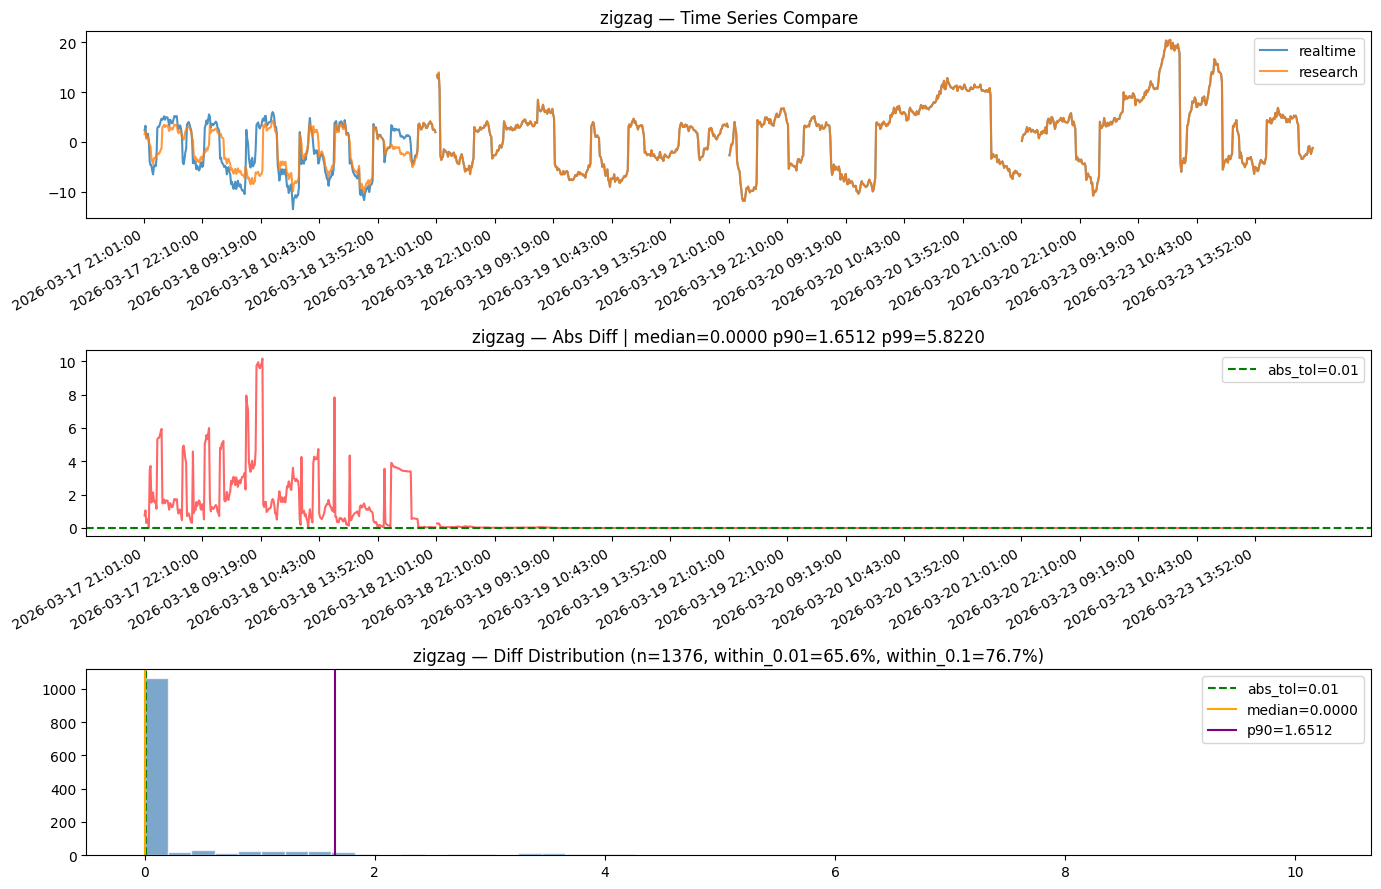

In [14]:
# ------------------- 单因子走势对比（3图：时序 + AbsDiff + 分布）-------------------
import matplotlib.pyplot as plt
%matplotlib inline

# 选择要查看的因子（可从上面问题因子中挑选，或手动修改）
VIEW_FACTOR = bad_factors[0] if bad_factors else common_factors[0]

# 基于完整对齐数据计算 diff
diff_full = (research_subset[VIEW_FACTOR] - rt_subset[VIEW_FACTOR]).abs()
valid_diff = diff_full.dropna()
idx_str = research_subset.index.astype(str)

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

if VIEW_FACTOR in rt_subset.columns:
    # 1. Time series compare
    axes[0].plot(idx_str, rt_subset[VIEW_FACTOR], label="realtime", alpha=0.8)
    axes[0].plot(idx_str, research_subset[VIEW_FACTOR], label="research", alpha=0.8)
    axes[0].set_title(f"{VIEW_FACTOR} — Time Series Compare")
    axes[0].legend()
    step = max(1, len(idx_str) // 20)
    axes[0].set_xticks(range(0, len(idx_str), step))
    axes[0].set_xticklabels(idx_str[::step], rotation=30, ha="right")

    # 2. Abs diff
    axes[1].plot(idx_str, diff_full, color="red", alpha=0.6)
    axes[1].axhline(TOL_ABS, color="green", linestyle="--", label=f"abs_tol={TOL_ABS}")
    p90 = valid_diff.quantile(0.90) if len(valid_diff) > 0 else np.nan
    p99 = valid_diff.quantile(0.99) if len(valid_diff) > 0 else np.nan
    med = valid_diff.median() if len(valid_diff) > 0 else np.nan
    axes[1].set_title(f"{VIEW_FACTOR} — Abs Diff | median={med:.4f} p90={p90:.4f} p99={p99:.4f}")
    axes[1].legend()
    axes[1].set_xticks(range(0, len(idx_str), step))
    axes[1].set_xticklabels(idx_str[::step], rotation=30, ha="right")

    # 3. Distribution histogram
    if len(valid_diff) > 0:
        axes[2].hist(valid_diff, bins=50, color="steelblue", edgecolor="white", alpha=0.7)
        axes[2].axvline(TOL_ABS, color="green", linestyle="--", label=f"abs_tol={TOL_ABS}")
        axes[2].axvline(med, color="orange", linestyle="-", label=f"median={med:.4f}")
        axes[2].axvline(p90, color="purple", linestyle="-", label=f"p90={p90:.4f}")
        w01 = (valid_diff < 0.01).mean()
        w1  = (valid_diff < 0.1).mean()
        axes[2].set_title(f"{VIEW_FACTOR} — Diff Distribution (n={len(valid_diff)}, within_0.01={w01:.1%}, within_0.1={w1:.1%})")
        axes[2].legend()
    else:
        axes[2].set_title("No valid diff data")

    plt.tight_layout()
    plt.show()
else:
    print(f"{VIEW_FACTOR} not in common factors")


In [15]:
# ------------------- 导出差异明细（可选）-------------------
output_dir = Path("/home/strategy_PAMY_dev/diff_analysis") / symbol
output_dir.mkdir(exist_ok=True, parents=True)

# 导出每个时间点的差异
diff_abs_output = diff_abs.copy()
diff_abs_output.index = diff_abs_output.index.strftime('%H:%M:%S')
diff_abs_output.T.to_csv(output_dir / "diff_abs_by_time.csv")
print(f"已导出: {output_dir / 'diff_abs_by_time.csv'}")

# 导出汇总
summary.round(6).to_csv(output_dir / "factor_summary.csv")
print(f"已导出: {output_dir / 'factor_summary.csv'}")


已导出: /home/strategy_PAMY_dev/save_files/P/diff_analysis/diff_abs_by_time.csv
已导出: /home/strategy_PAMY_dev/save_files/P/diff_analysis/factor_summary.csv
已导出: /home/strategy_PAMY_dev/save_files/P/diff_analysis/factor_comparison.xlsx


In [15]:
# ------------------- 交互式查看（修改下方变量）-------------------
# 修改以下两个变量来查看任意因子在任意时间点的原始值
VIEW_FACTOR = bad_factors[0] if bad_factors else common_factors[0]
VIEW_TIME = common_index[0]

print(f"=== 因子: {VIEW_FACTOR} @ {VIEW_TIME.strftime('%H:%M:%S')} ===")
print(f"research: {research_subset.loc[VIEW_TIME, VIEW_FACTOR]}")
print(f"realtime: {rt_subset.loc[VIEW_TIME, VIEW_FACTOR]}")
print(f"abs_diff: {diff_abs.loc[VIEW_TIME, VIEW_FACTOR]}")

# 显示该因子前后5分钟的数据
idx_pos = common_index.get_loc(VIEW_TIME)
start_pos = max(0, idx_pos - 5)
end_pos = min(len(common_index), idx_pos + 6)

compare_df = pd.DataFrame({
    '时间': common_index[start_pos:end_pos].strftime('%H:%M:%S'),
    'research': research_subset[VIEW_FACTOR].iloc[start_pos:end_pos].values,
    'realtime': rt_subset[VIEW_FACTOR].iloc[start_pos:end_pos].values,
    'abs_diff': diff_abs[VIEW_FACTOR].iloc[start_pos:end_pos].values,
})
print("前后5分钟对比:")
display(compare_df.round(6))

=== 因子: zigzag @ 21:01:00 ===
research: nan
realtime: nan
abs_diff: nan
前后5分钟对比:


,时间,research,realtime,abs_diff
0,21:01:00,NaN,NaN,NaN
1,21:02:00,1.568115,2.319961,0.751846
2,21:03:00,2.195361,3.249516,1.054155
3,21:04:00,0.627246,0.928882,0.301636
4,21:05:00,0.940869,1.393998,0.453129
5,21:06:00,1.097680,1.627119,0.529438


## 预测值对比

加载 5-fold LightGBM 模型，分别计算研究环境和实时环境的预测值，并排对比。

In [16]:
# ------------------- 配置 -------------------
MODEL_ROOT = "/home/strategy_PAMY_dev/models"
# -------------------------------------------

In [17]:
# ------------------- 计算研究环境预测值 -------------------
import lightgbm as lgb
import json

model_lst = []
weight_lst = []
for i in range(1, 6):
    model_file = f"{MODEL_ROOT}/{symbol}/kfold_fold{i}_0.lgb"
    meta_file = f"{MODEL_ROOT}/{symbol}/kfold_fold{i}_0_meta.json"
    m = lgb.Booster(model_file=model_file)
    with open(meta_file, 'r') as f:
        meta_data = json.load(f)
    model_lst.append(m)
    weight_lst.append(float(np.log(meta_data['best_iteration'] + 1)))

print(f"Loaded {len(model_lst)} models | weights: {[round(w, 3) for w in weight_lst]}")

factor_col = model_lst[0].feature_name()
rs_input = research_subset[[c for c in factor_col if c in research_subset.columns]].copy()
if 'hour' not in rs_input.columns:
    rs_input['hour'] = rs_input.index.hour
rs_input = rs_input[factor_col]

pred_res = pd.DataFrame(
    [m.predict(rs_input) for m in model_lst],
    columns=rs_input.index,
    index=[f'model_{i+1}' for i in range(len(model_lst))]
).T
pred_res['weighted'] = pred_res.mul(weight_lst, axis=1).sum(axis=1) / sum(weight_lst)
pred_res['weighted_s'] = (
    pred_res['weighted'] * 0.6
    + pred_res['weighted'].shift(1) * 0.3
    + pred_res['weighted'].shift(2) * 0.1
)
print(f"[研究预测] shape: {pred_res.shape}")

Loaded 5 models | weights: [5.956, 4.382, 6.387, 7.473, 6.936]
[研究预测] shape: (1380, 7)


In [18]:
# ------------------- 加载实时测试环境预测值 -------------------
rt_pred_dir = Path(RT_MIN_PREFIX) / symbol / "predictions"
rt_pred_files = sorted(rt_pred_dir.glob("predictions_*.csv"))
if not rt_pred_files:
    raise FileNotFoundError(f"未找到实时预测值: {rt_pred_dir}")

pred_dfs = []
for f in rt_pred_files:
    pred_dfs.append(pd.read_csv(f, parse_dates=['datetime']))
pred_rt = pd.concat(pred_dfs, ignore_index=True).sort_values('datetime').set_index('datetime')

print(f"[实时预测] 文件数: {len(rt_pred_files)}, 总行数: {len(pred_rt)}")
pred_rt.tail(TAIL_N)


[实时预测] 文件数: 196, 总行数: 1960


,model_1,model_2,model_3,model_4,model_5,weighted,weighted_s,signal
datetime,,,,,,,,
2026-05-25 21:13:00,-0.043858,0.006156,-0.037728,-0.025974,-0.011811,-0.024129,-0.020252,未开仓
2026-05-25 21:14:00,-0.034133,-0.005180,-0.028588,-0.053223,-0.028695,-0.032291,-0.027947,未开仓
2026-05-25 21:14:00,-0.034133,-0.005180,-0.028588,-0.053223,-0.028695,-0.032291,-0.027947,未开仓
2026-05-25 21:14:00,-0.034133,-0.005180,-0.028588,-0.053223,-0.028695,-0.032291,-0.027947,未开仓
2026-05-25 21:14:00,-0.034133,-0.005180,-0.028588,-0.053223,-0.028695,-0.032291,-0.027947,未开仓
2026-05-25 21:14:00,-0.034133,-0.005180,-0.028588,-0.053223,-0.028695,-0.032291,-0.027947,未开仓
2026-05-25 21:14:00,-0.034133,-0.005180,-0.028588,-0.053223,-0.028695,-0.032291,-0.027947,未开仓
2026-05-25 21:14:00,-0.034133,-0.005180,-0.028588,-0.053223,-0.028695,-0.032291,-0.027947,未开仓
2026-05-25 21:14:00,-0.034133,-0.005180,-0.028588,-0.053223,-0.028695,-0.032291,-0.027947,未开仓


In [19]:
# ------------------- 预测对齐 -------------------
pred_common = pred_res.index.intersection(rt_pred.index)
print(f"[预测对齐] 共有时间点: {len(pred_common)} 个")

pred_res = pred_res.loc[pred_common]
rt_pred = rt_pred.loc[pred_common]

diff_w = (rt_pred['weighted'] - pred_res['weighted']).abs()
diff_ws = (rt_pred['weighted_s'] - pred_res['weighted_s']).abs()

print(f"weighted   max_diff={diff_w.max():.4f}  mean_diff={diff_w.mean():.4f}")
print(f"weighted_s max_diff={diff_ws.max():.4f}  mean_diff={diff_ws.mean():.4f}")

NameError: name 'rt_pred' is not defined

In [20]:
# ------------------- 预测值 tail 对比 -------------------
TAIL_PRED = 20
print("=== 研究预测 tail ===")
display(pred_res.tail(TAIL_PRED).round(6))
print("\n=== 实时预测 tail ===")
display(rt_pred.tail(TAIL_PRED).round(6))
print("\n=== 预测 diff ===")
display((pred_res.tail(TAIL_PRED) - rt_pred.tail(TAIL_PRED)).round(4))

=== 研究预测 tail ===


,model_1,model_2,model_3,model_4,model_5,weighted,weighted_s
datetime,,,,,,,
2026-03-23 14:41:00,-0.002371,0.002207,-0.003184,-0.030531,-0.020574,-0.012708,-0.007490
2026-03-23 14:42:00,0.018221,0.000582,0.012466,-0.024327,0.001555,0.000632,-0.003664
2026-03-23 14:43:00,0.012411,0.001749,0.010428,-0.000977,0.000466,0.004629,0.001696
2026-03-23 14:44:00,0.008580,0.001861,0.012099,0.009692,0.011338,0.009238,0.006994
2026-03-23 14:45:00,0.015424,0.002501,0.009030,0.011736,-0.000812,0.007791,0.007909
2026-03-23 14:46:00,0.024363,0.000271,0.009020,-0.002094,0.006225,0.007434,0.007721
2026-03-23 14:47:00,0.010306,0.003100,0.008025,0.009852,0.007281,0.008041,0.007834
2026-03-23 14:48:00,0.018159,0.002598,-0.004584,-0.004093,-0.003364,0.001167,0.003856
2026-03-23 14:49:00,0.007958,0.002728,-0.002395,-0.011524,0.011621,0.001238,0.001897



=== 实时预测 tail ===


NameError: name 'rt_pred' is not defined